# Experiment 4 — Comparative Study of Deep CNN Architectures Using Transfer Learning



In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import VGG16, ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam, SGD

from sklearn.metrics import (precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report)

np.random.seed(42)
tf.random.set_seed(42)

class_names = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer',
               'Dog', 'Frog', 'Horse', 'Ship', 'Truck']


In [2]:
import time

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1889s 11us/step
Training data shape : (50000, 32, 32, 3)
Training labels shape: (50000, 1)
Testing data shape   : (10000, 32, 32, 3)
Testing labels shape : (10000, 1)


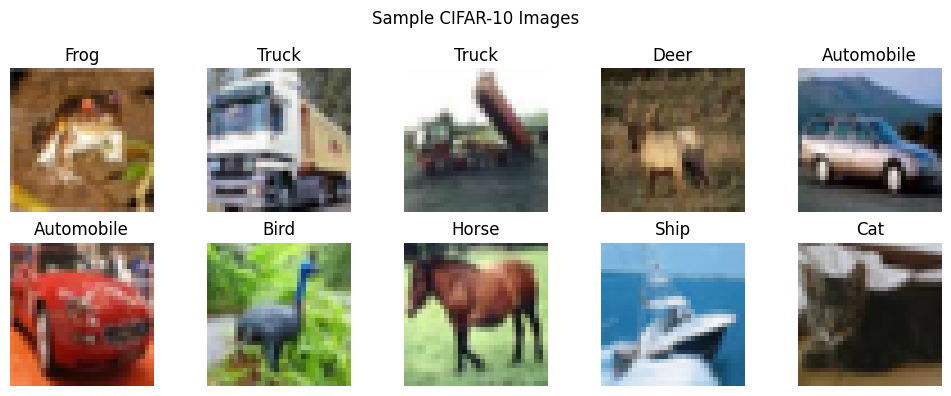

In [3]:
# 1 & 4. Load CIFAR-10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# 4. Print dimensions
print("Training data shape :", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Testing data shape   :", x_test.shape)
print("Testing labels shape :", y_test.shape)

# 2. Normalize pixel values to [0, 1]
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm  = x_test.astype('float32') / 255.0

# 3. Display 10 sample images  (Mandatory Plot 1)
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')
plt.suptitle("Sample CIFAR-10 Images")
plt.tight_layout()
plt.show()

# 5. One-hot encode labels
y_train_cat = to_categorical(y_train, 10)
y_test_cat  = to_categorical(y_test, 10)


## Task 2 — Transfer Learning: Build the VGG16 Model



In [ ]:
# 1. Load pretrained VGG16 (convolutional base only)
base_model_vgg = VGG16(weights='imagenet', include_top=False, input_shape=(32, 32, 3))

# 2. Freeze the convolutional base
for layer in base_model_vgg.layers:
    layer.trainable = False

# 3-5. Add new classifier head
x = GlobalAveragePooling2D()(base_model_vgg.output)
x = Dense(256, activation='relu')(x)
output = Dense(10, activation='softmax')(x)

vgg_model = Model(inputs=base_model_vgg.input, outputs=output)

# 6. Summary
vgg_model.summary()

# 7. VGG16-specific preprocessing (mean subtraction / channel ordering that
#    matches how the ImageNet weights were trained)
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess

x_train_vgg = vgg_preprocess(x_train.astype('float32').copy())
x_test_vgg  = vgg_preprocess(x_test.astype('float32').copy())


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 133,898 (523.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

## Task 3 — Model Training (frozen base)


In [ ]:
vgg_model.compile(optimizer=Adam(learning_rate=0.001),
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])

start_time = time.time()

history_vgg = vgg_model.fit(
    x_train_vgg,
    y_train_cat,
    validation_data=(x_test_vgg, y_test_cat),
    batch_size=32,
    epochs=10
)

vgg_training_time = time.time() - start_time

print(f"VGG16 Training Time: {vgg_training_time:.2f} seconds")
print(f"VGG16 Training Time: {vgg_training_time/60:.2f} minutes")

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.5663 - loss: 1.8695 - val_accuracy: 0.6208 - val_loss: 1.1021
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.6691 - loss: 0.9618 - val_accuracy: 0.6350 - val_loss: 1.0815
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.7033 - loss: 0.8550 - val_accuracy: 0.6398 - val_loss: 1.1136
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.7296 - loss: 0.7739 - val_accuracy: 0.6397 - val_loss: 1.1791
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.7546 - loss: 0.6974 - val_accuracy: 0.6334 - val_loss: 1.2755
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.7814 - loss: 0.6227 - val_accuracy: 0.6306 - val_loss: 1.3673
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.8041 - loss: 0.5585 - val_accuracy: 0.6296 - val_loss: 1.4882
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.8205 -

## Task 4 — Fine Tuning


In [ ]:
# 1. Unfreeze last convolution block only (block5)
for layer in base_model_vgg.layers:
    if layer.name.startswith('block5'):
        layer.trainable = True
    else:
        layer.trainable = False

# Confirm which layers are now trainable
for layer in base_model_vgg.layers:
    print(f"{layer.name:15s} trainable={layer.trainable}")

# 2. Re-compile with a smaller learning rate
vgg_model.compile(optimizer=Adam(learning_rate=0.0001),
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])

# 3. Continue training (fine-tuning)
start_time = time.time()

history_vgg_finetune = vgg_model.fit(
    x_train_vgg,
    y_train_cat,
    validation_data=(x_test_vgg, y_test_cat),
    batch_size=32,
    epochs=5
)

vgg_finetune_time = time.time() - start_time

print(f"VGG16 Fine-tuning Time: {vgg_finetune_time:.2f} seconds")
print(f"VGG16 Fine-tuning Time: {vgg_finetune_time/60:.2f} minutes")

# 4. Compare accuracy before and after fine-tuning
acc_before = history_vgg.history['val_accuracy'][-1]
acc_after  = history_vgg_finetune.history['val_accuracy'][-1]
print(f"\nValidation Accuracy before fine-tuning: {acc_before:.4f}")
print(f"Validation Accuracy after  fine-tuning: {acc_after:.4f}")


input_layer_7   trainable=False
block1_conv1    trainable=False
block1_conv2    trainable=False
block1_pool     trainable=False
block2_conv1    trainable=False
block2_conv2    trainable=False
block2_pool     trainable=False
block3_conv1    trainable=False
block3_conv2    trainable=False
block3_conv3    trainable=False
block3_pool     trainable=False
block4_conv1    trainable=False
block4_conv2    trainable=False
block4_conv3    trainable=False
block4_pool     trainable=False
block5_conv1    trainable=True
block5_conv2    trainable=True
block5_conv3    trainable=True
block5_pool     trainable=True
Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 28s 16ms/step - accuracy: 0.6651 - loss: 1.0143 - val_accuracy: 0.7357 - val_loss: 0.7992
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.7644 - loss: 0.6954 - val_accuracy: 0.7578 - val_loss: 0.7504
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.8092 - loss: 0.5470 - val_accuracy: 0.7669 - val_loss: 0.7556
Epo

In [ ]:
vgg_total_time = vgg_training_time + vgg_finetune_time

print(f"VGG16 Total Training Time: {vgg_total_time:.2f} seconds")
print(f"VGG16 Total Training Time: {vgg_total_time/60:.2f} minutes")

VGG16 Total Training Time: 275.69 seconds
VGG16 Total Training Time: 4.59 minutes


## Task 5 — Model Evaluation



In [ ]:
# 1. Predict on test set
y_pred_probs = vgg_model.predict(x_test_vgg)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test.flatten()

# 2. Metrics
test_loss, test_accuracy = vgg_model.evaluate(x_test_vgg, y_test_cat, verbose=0)
precision = precision_score(y_true, y_pred, average='macro')
recall    = recall_score(y_true, y_pred, average='macro')
f1        = f1_score(y_true, y_pred, average='macro')

print(f"Testing Accuracy : {test_accuracy:.4f}")
print(f"Precision (macro): {precision:.4f}")
print(f"Recall (macro)   : {recall:.4f}")
print(f"F1-score (macro) : {f1:.4f}")

# 3. Classification report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

# 4. Confusion matrix (used in the mandatory plots section below)
cm = confusion_matrix(y_true, y_pred)


313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step
Testing Accuracy : 0.7626
Precision (macro): 0.7660
Recall (macro)   : 0.7626
F1-score (macro) : 0.7579

Classification Report:

              precision    recall  f1-score   support

    Airplane       0.73      0.88      0.80      1000
  Automobile       0.85      0.88      0.86      1000
        Bird       0.75      0.71      0.73      1000
         Cat       0.70      0.44      0.54      1000
        Deer       0.66      0.74      0.70      1000
         Dog       0.73      0.64      0.68      1000
        Frog       0.84      0.80      0.82      1000
       Horse       0.68      0.91      0.78      1000
        Ship       0.84      0.87      0.86      1000
       Truck       0.89      0.76      0.82      1000

    accuracy                           0.76     10000
   macro avg       0.77      0.76      0.76     10000
weighted avg       0.77      0.76      0.76     10000



### Plot 2 — Training vs Validation Accuracy



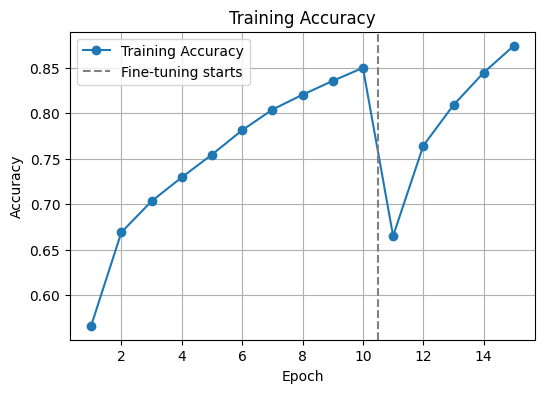

In [ ]:
train_acc = (
    history_vgg.history['accuracy']
    + history_vgg_finetune.history['accuracy']
)

switch_epoch = len(history_vgg.history['accuracy'])

plt.figure(figsize=(6, 4))

plt.plot(
    range(1, len(train_acc) + 1),
    train_acc,
    marker='o',
    label='Training Accuracy'
)

plt.axvline(
    x=switch_epoch + 0.5,
    color='gray',
    linestyle='--',
    label='Fine-tuning starts'
)

plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

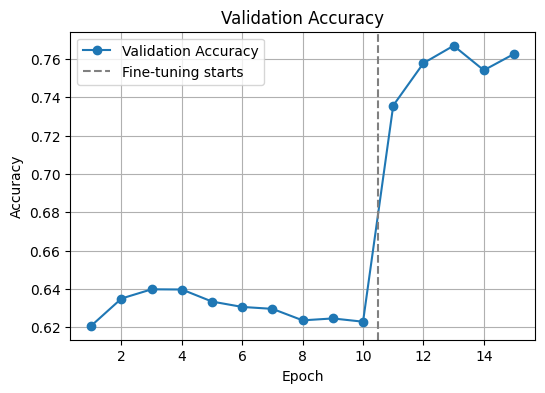

In [ ]:
val_acc = (
    history_vgg.history['val_accuracy']
    + history_vgg_finetune.history['val_accuracy']
)

switch_epoch = len(history_vgg.history['val_accuracy'])

plt.figure(figsize=(6, 4))

plt.plot(
    range(1, len(val_acc) + 1),
    val_acc,
    marker='o',
    label='Validation Accuracy'
)

plt.axvline(
    x=switch_epoch + 0.5,
    color='gray',
    linestyle='--',
    label='Fine-tuning starts'
)

plt.title('Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

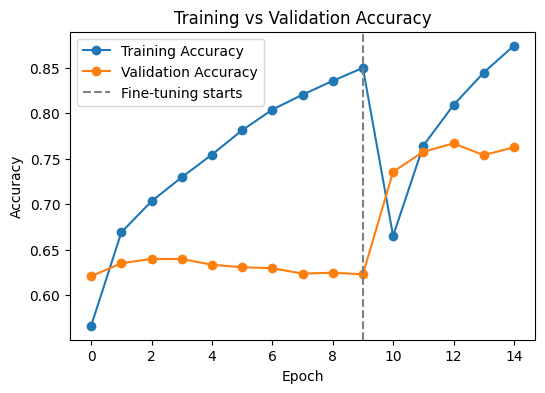

In [ ]:
train_acc = history_vgg.history['accuracy'] + history_vgg_finetune.history['accuracy']
val_acc   = history_vgg.history['val_accuracy'] + history_vgg_finetune.history['val_accuracy']
switch_epoch = len(history_vgg.history['accuracy']) - 1

plt.figure(figsize=(6, 4))
plt.plot(train_acc, marker='o', label='Training Accuracy')
plt.plot(val_acc, marker='o', label='Validation Accuracy')
plt.axvline(x=switch_epoch, color='gray', linestyle='--', label='Fine-tuning starts')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


**Inference:** Training accuracy rises steadily during the frozen phase as
the new dense head learns to use VGG16's pretrained features, with a further
bump usually visible right after fine-tuning starts since the last convolution
block can now adapt to CIFAR-10 specifically. Validation accuracy tracking
close to training accuracy indicates the model is not overfitting badly; a
growing gap between the two lines would be a sign of overfitting.


### Plot 3 — Training vs Validation Loss


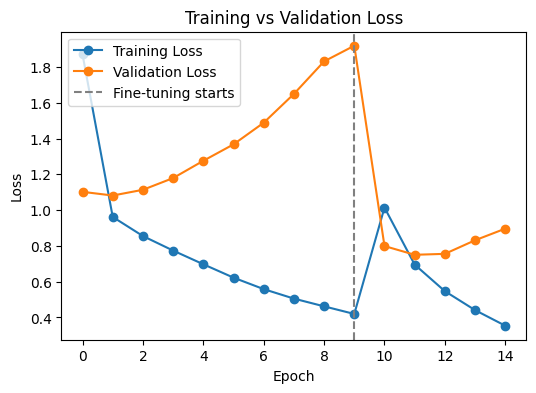

In [ ]:
train_loss = history_vgg.history['loss'] + history_vgg_finetune.history['loss']
val_loss   = history_vgg.history['val_loss'] + history_vgg_finetune.history['val_loss']

plt.figure(figsize=(6, 4))
plt.plot(train_loss, marker='o', label='Training Loss')
plt.plot(val_loss, marker='o', label='Validation Loss')
plt.axvline(x=switch_epoch, color='gray', linestyle='--', label='Fine-tuning starts')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


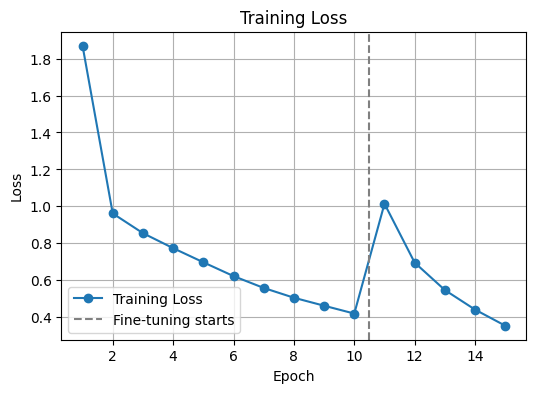

In [ ]:
train_loss = history_vgg.history['loss'] + history_vgg_finetune.history['loss']
switch_epoch = len(history_vgg.history['loss'])
plt.figure(figsize=(6,4))
plt.plot(range(1, len(train_loss)+1), train_loss, marker='o', label='Training Loss')
plt.axvline(x=switch_epoch+0.5, color='gray', linestyle='--', label='Fine-tuning starts')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

**Inference:** Training loss decreases steadily as the classifier head
learns, with a possible small jump right at the fine-tuning boundary because
the optimizer state resets when block5 becomes trainable. A validation loss
that keeps falling (or stays flat) alongside training loss confirms the model
generalizes well; a validation loss that starts rising while training loss
keeps falling would indicate overfitting.


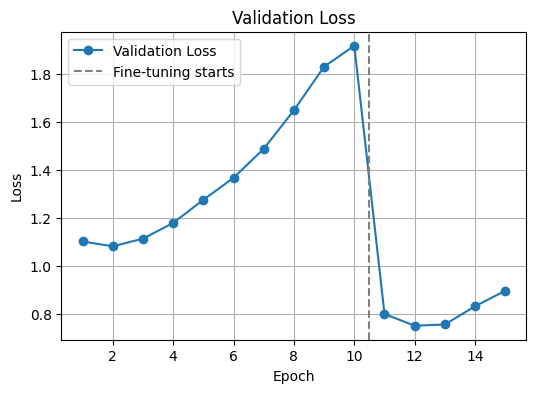

In [ ]:
val_loss = history_vgg.history['val_loss'] + history_vgg_finetune.history['val_loss']
switch_epoch = len(history_vgg.history['val_loss'])
plt.figure(figsize=(6,4))
plt.plot(range(1, len(val_loss)+1), val_loss, marker='o', label='Validation Loss')
plt.axvline(x=switch_epoch+0.5, color='gray', linestyle='--', label='Fine-tuning starts')
plt.title('Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

### Plot 4 — Confusion Matrix


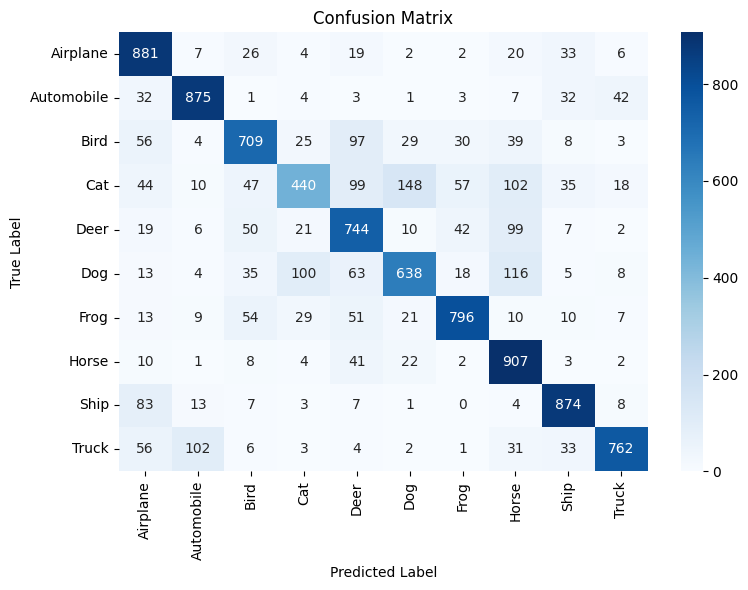

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()


**Inference:** The diagonal cells (correct predictions) should have the
highest counts. Visually related classes such as Cat/Dog or Automobile/Truck
typically show the most confusion since they share similar shapes and colours
at 32×32 resolution.


### Plot 5 — Misclassified Images (Optional)



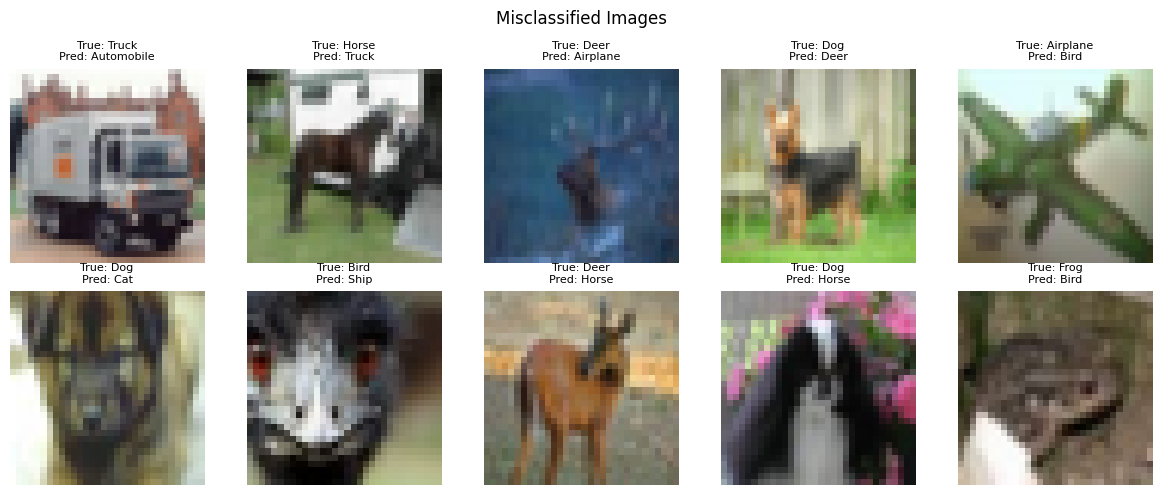

In [ ]:
wrong_idx = np.where(y_pred != y_true)[0][:10]

plt.figure(figsize=(12, 5))
for i, idx in enumerate(wrong_idx):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[idx])
    plt.title(f"True: {class_names[y_true[idx]]}\nPred: {class_names[y_pred[idx]]}", fontsize=8)
    plt.axis('off')
plt.suptitle("Misclassified Images")
plt.tight_layout()
plt.show()


**Inference:** Misclassifications are usually concentrated among visually
similar classes (e.g., Deer vs Horse, Cat vs Dog), confirming the confusion
matrix pattern above.


## Additional Exercise — Repeat with ResNet50



In [ ]:
# 1. Build ResNet50 transfer-learning model
base_model_resnet = ResNet50(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
for layer in base_model_resnet.layers:
    layer.trainable = False

x = GlobalAveragePooling2D()(base_model_resnet.output)
x = Dense(256, activation='relu')(x)
output = Dense(10, activation='softmax')(x)
resnet_model = Model(inputs=base_model_resnet.input, outputs=output)

# 2. ResNet50-specific preprocessing (mean subtraction / channel ordering
#    that matches how the ImageNet weights were trained). This matches the
#    input distribution to what the frozen BatchNorm layers expect.
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess

x_train_resnet = resnet_preprocess(x_train.astype('float32').copy())
x_test_resnet  = resnet_preprocess(x_test.astype('float32').copy())

# 3. Train with frozen base
resnet_model.compile(optimizer=Adam(learning_rate=0.001),
                      loss='categorical_crossentropy',
                      metrics=['accuracy'])

history_resnet = resnet_model.fit(x_train_resnet, y_train_cat,
                                   validation_data=(x_test_resnet, y_test_cat),
                                   batch_size=32,
                                   epochs=10)

# 4. Fine-tune last convolution block (conv5)
for layer in base_model_resnet.layers:
    if layer.name.startswith('conv5'):
        layer.trainable = True
    else:
        layer.trainable = False

resnet_model.compile(optimizer=Adam(learning_rate=0.0001),
                      loss='categorical_crossentropy',
                      metrics=['accuracy'])

start_time = time.time()
history_resnet_finetune = resnet_model.fit(x_train_resnet, y_train_cat,
                                            validation_data=(x_test_resnet, y_test_cat),
                                            batch_size=32,
                                            epochs=5)
resnet_training_time = time.time() - start_time
print(f"ResNet50 Training Time: {resnet_training_time/60:.2f} minutes")

# 5. Final evaluation
resnet_test_loss, resnet_test_acc = resnet_model.evaluate(x_test_resnet, y_test_cat, verbose=0)
print(f"ResNet50 Final Testing Accuracy: {resnet_test_acc:.4f}")


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 36s 17ms/step - accuracy: 0.6091 - loss: 1.1564 - val_accuracy: 0.6457 - val_loss: 1.0199
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.6836 - loss: 0.8976 - val_accuracy: 0.6581 - val_loss: 1.0085
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.7222 - loss: 0.7852 - val_accuracy: 0.6536 - val_loss: 1.0405
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.7586 - loss: 0.6821 - val_accuracy: 0.6570 - val_loss: 1.0969
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.7928 - loss: 0.5857 - val_accuracy: 0.6400 - val_loss: 1.2222
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.8230 - loss: 0.5013 - val_accuracy: 0.6349 - val_loss: 1.3452
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.8469 - loss: 0.4300 - val_accuracy: 0.6305 - val_loss: 1.4852
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.8662 - loss

**Inference:** With `preprocess_input` matching ResNet50's expected input
distribution, the frozen ImageNet BatchNorm statistics are now meaningful for
these inputs, so accuracy should come out much closer to (or better than)
VGG16's, instead of the artificially low value you'd get from feeding raw
`[0,1]`-scaled pixels into a network whose frozen layers expect ImageNet-style
preprocessing.


## Additional Exercise — Build LeNet-5, AlexNet, and GoogleNet from Scratch



In [ ]:
# ----------------------- LeNet-5 -----------------------
from tensorflow.keras.layers import Conv2D, AveragePooling2D, Flatten

lenet_model = tf.keras.Sequential([
    Conv2D(6, kernel_size=5, activation='relu', padding='same', input_shape=(32, 32, 3)),
    AveragePooling2D(pool_size=2),
    Conv2D(16, kernel_size=5, activation='relu'),
    AveragePooling2D(pool_size=2),
    Flatten(),
    Dense(120, activation='relu'),
    Dense(84, activation='relu'),
    Dense(10, activation='softmax')
])

lenet_model.compile(optimizer=Adam(learning_rate=0.001),
                     loss='categorical_crossentropy',
                     metrics=['accuracy'])

print("Training LeNet-5...")
start_time = time.time()

history_lenet = lenet_model.fit(x_train_norm, y_train_cat, validation_data=(x_test_norm, y_test_cat), batch_size=32, epochs=10)

lenet_training_time = time.time() - start_time
print(f"LeNet-5 Training Time: {lenet_training_time/60:.2f} minutes")

lenet_test_loss, lenet_test_acc = lenet_model.evaluate(x_test_norm, y_test_cat, verbose=0)
print(f"LeNet-5 Final Testing Accuracy: {lenet_test_acc:.4f}")
print(f"LeNet-5 Parameters: {lenet_model.count_params():,}")

# --------------------- AlexNet (CIFAR-adapted) ---------------------
from tensorflow.keras.layers import MaxPooling2D, Dropout, BatchNormalization

alexnet_model = tf.keras.Sequential([
    Conv2D(64, kernel_size=3, strides=1, activation='relu', padding='same', input_shape=(32, 32, 3)),
    BatchNormalization(),
    MaxPooling2D(pool_size=2),

    Conv2D(192, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=2),

    Conv2D(384, kernel_size=3, activation='relu', padding='same'),
    Conv2D(256, kernel_size=3, activation='relu', padding='same'),
    Conv2D(256, kernel_size=3, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=2),

    Flatten(),
    Dense(1024, activation='relu'),
    Dropout(0.5),
    Dense(1024, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

alexnet_model.compile(optimizer=Adam(learning_rate=0.001),
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])

print("\\nTraining AlexNet (CIFAR-adapted)...")

start_time = time.time()
history_alexnet = alexnet_model.fit(x_train_norm, y_train_cat,
                                     validation_data=(x_test_norm, y_test_cat),
                                     batch_size=32, epochs=10, verbose=1)

alexnet_training_time = time.time() - start_time
print(f"AlexNet Training Time: {alexnet_training_time/60:.2f} minutes")

alexnet_test_loss, alexnet_test_acc = alexnet_model.evaluate(x_test_norm, y_test_cat, verbose=0)
print(f"AlexNet Final Testing Accuracy: {alexnet_test_acc:.4f}")
print(f"AlexNet Parameters: {alexnet_model.count_params():,}")

# --------------------- GoogleNet (compact Inception-style) ---------------------
from tensorflow.keras.layers import Input, Concatenate

def inception_module(x, f1x1, f3x3_reduce, f3x3, f5x5_reduce, f5x5, pool_proj):
    """One Inception module: four parallel branches concatenated together,
    exactly the idea described in Section 9 of the manual."""
    conv1 = Conv2D(f1x1, (1, 1), padding='same', activation='relu')(x)

    conv3 = Conv2D(f3x3_reduce, (1, 1), padding='same', activation='relu')(x)
    conv3 = Conv2D(f3x3, (3, 3), padding='same', activation='relu')(conv3)

    conv5 = Conv2D(f5x5_reduce, (1, 1), padding='same', activation='relu')(x)
    conv5 = Conv2D(f5x5, (5, 5), padding='same', activation='relu')(conv5)

    pool = MaxPooling2D((3, 3), strides=(1, 1), padding='same')(x)
    pool = Conv2D(pool_proj, (1, 1), padding='same', activation='relu')(pool)

    return Concatenate(axis=-1)([conv1, conv3, conv5, pool])

inputs = Input(shape=(32, 32, 3))
g = Conv2D(64, (3, 3), padding='same', activation='relu')(inputs)
g = MaxPooling2D((2, 2))(g)

g = inception_module(g, 64, 96, 128, 16, 32, 32)
g = inception_module(g, 128, 128, 192, 32, 96, 64)
g = MaxPooling2D((2, 2))(g)

g = inception_module(g, 192, 96, 208, 16, 48, 64)
g = GlobalAveragePooling2D()(g)
g_output = Dense(10, activation='softmax')(g)

googlenet_model = Model(inputs=inputs, outputs=g_output)


googlenet_model.compile(optimizer=Adam(learning_rate=0.001),
                         loss='categorical_crossentropy',
                         metrics=['accuracy'])

print("\\nTraining GoogleNet (compact Inception-style)...")

start_time = time.time()
history_googlenet = googlenet_model.fit(x_train_norm, y_train_cat,
                                         validation_data=(x_test_norm, y_test_cat),
                                         batch_size=32, epochs=10, verbose=1)

googlenet_training_time = time.time() - start_time
print(f"GoogleNet Training Time: {googlenet_training_time/60:.2f} minutes")

googlenet_test_loss, googlenet_test_acc = googlenet_model.evaluate(x_test_norm, y_test_cat, verbose=0)
print(f"GoogleNet Final Testing Accuracy: {googlenet_test_acc:.4f}")
print(f"GoogleNet Parameters: {googlenet_model.count_params():,}")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training LeNet-5...
Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.4095 - loss: 1.6346 - val_accuracy: 0.4917 - val_loss: 1.4091
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5202 - loss: 1.3441 - val_accuracy: 0.5392 - val_loss: 1.2842
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.5631 - loss: 1.2240 - val_accuracy: 0.5580 - val_loss: 1.2563
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.5944 - loss: 1.1359 - val_accuracy: 0.5763 - val_loss: 1.2001
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6199 - loss: 1.0668 - val_accuracy: 0.5901 - val_loss: 1.1758
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.6436 - loss: 1.0066 - val_accuracy: 0.5898 - val_loss: 1.1845
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6624 - loss: 0.9541 - val_accuracy: 0.5933 - val_loss: 1.1817
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0

**Inference:** LeNet-5 is tiny (a few hundred thousand parameters) and
was designed for simple grayscale digit images, so it typically underperforms
on 10-class colour CIFAR-10 compared to deeper networks. The CIFAR-adapted
AlexNet has many more parameters and layers and should score noticeably
higher. The compact GoogleNet-style network usually lands somewhere between
the two in accuracy despite having relatively few parameters — reflecting the
real Inception module's design goal of extracting rich multi-scale features
efficiently. All three are trained from scratch here — unlike VGG16/ResNet50,
they get no head-start from ImageNet pretraining, so they generally need more
epochs to reach the accuracy the transfer-learning models achieve much faster.


## Additional Exercise — Compare Adam vs SGD Optimizers



Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 12ms/step - accuracy: 0.5657 - loss: 1.8532 - val_accuracy: 0.6211 - val_loss: 1.1014
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.6680 - loss: 0.9610 - val_accuracy: 0.6421 - val_loss: 1.0682
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 10ms/step - accuracy: 0.7010 - loss: 0.8598 - val_accuracy: 0.6447 - val_loss: 1.0916
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.7269 - loss: 0.7833 - val_accuracy: 0.6398 - val_loss: 1.1568
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.7511 - loss: 0.7092 - val_accuracy: 0.6471 - val_loss: 1.2089
Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 12ms/step - accuracy: 0.5582 - loss: 1.5961 - val_accuracy: 0.6012 - val_loss: 1.1723
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.6499 - loss: 1.0063 - val_accuracy: 0.6173 - val_loss: 1.1447
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.6870 - loss: 0

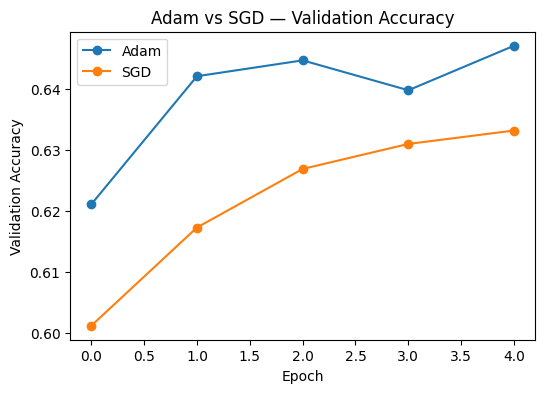

In [ ]:
def build_vgg_model():
    base = VGG16(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
    for layer in base.layers:
        layer.trainable = False
    x = GlobalAveragePooling2D()(base.output)
    x = Dense(256, activation='relu')(x)
    out = Dense(10, activation='softmax')(x)
    return Model(inputs=base.input, outputs=out)

# Adam
model_adam = build_vgg_model()
model_adam.compile(optimizer=Adam(learning_rate=0.001),
                    loss='categorical_crossentropy', metrics=['accuracy'])
history_adam = model_adam.fit(x_train_vgg, y_train_cat,
                               validation_data=(x_test_vgg, y_test_cat),
                               batch_size=32, epochs=5)

# SGD
model_sgd = build_vgg_model()
model_sgd.compile(optimizer=SGD(learning_rate=0.001, momentum=0.9),
                   loss='categorical_crossentropy', metrics=['accuracy'])
history_sgd = model_sgd.fit(x_train_vgg, y_train_cat,
                             validation_data=(x_test_vgg, y_test_cat),
                             batch_size=32, epochs=5)

print(f"Adam - Final Validation Accuracy: {history_adam.history['val_accuracy'][-1]:.4f}")
print(f"SGD  - Final Validation Accuracy: {history_sgd.history['val_accuracy'][-1]:.4f}")

plt.figure(figsize=(6, 4))
plt.plot(history_adam.history['val_accuracy'], marker='o', label='Adam')
plt.plot(history_sgd.history['val_accuracy'], marker='o', label='SGD')
plt.title('Adam vs SGD — Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.show()


**Inference:** Adam typically converges faster in the first few epochs
because it adapts the learning rate per parameter, while plain SGD with
momentum tends to need more epochs to reach a comparable accuracy, but can
sometimes generalize slightly better over longer training.


## Additional Exercise — Frozen vs Fine-Tuned Comparison


VGG16 Frozen (before fine-tuning) Validation Accuracy: 0.6229
VGG16 Fine-tuned Validation Accuracy               : 0.7626


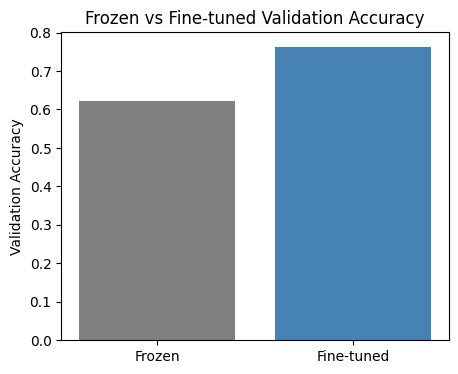

In [ ]:
frozen_acc    = history_vgg.history['val_accuracy'][-1]
finetuned_acc = history_vgg_finetune.history['val_accuracy'][-1]

print(f"VGG16 Frozen (before fine-tuning) Validation Accuracy: {frozen_acc:.4f}")
print(f"VGG16 Fine-tuned Validation Accuracy               : {finetuned_acc:.4f}")

plt.figure(figsize=(5, 4))
plt.bar(['Frozen', 'Fine-tuned'], [frozen_acc, finetuned_acc], color=['gray', 'steelblue'])
plt.title('Frozen vs Fine-tuned Validation Accuracy')
plt.ylabel('Validation Accuracy')
plt.show()


**Inference:** Fine-tuning the last convolution block usually improves
accuracy over the frozen-base model because those higher-level filters can
adapt from generic ImageNet features to CIFAR-10-specific features, at the
cost of extra training time.


## Comparison Table (Section 18.2)


In [ ]:
print("LeNet-5:", lenet_model.count_params())
print("AlexNet:", alexnet_model.count_params())
print("VGG16:", vgg_model.count_params())
print("GoogleNet:", googlenet_model.count_params())
print("ResNet50:", resnet_model.count_params())

LeNet-5: 83126
AlexNet: 7508810
VGG16: 14848586
GoogleNet: 908906
ResNet50: 24114826


In [ ]:
import pandas as pd

comparison_table = pd.DataFrame({
    'Model': ['LeNet-5', 'AlexNet', 'VGG16', 'GoogleNet', 'ResNet50'],
    'Parameters': [
        f"{lenet_model.count_params():,}",
        f"{alexnet_model.count_params():,}",
        f"{vgg_model.count_params():,}",
        f"{googlenet_model.count_params():,}",
        f"{resnet_model.count_params():,}"
    ],
    'Accuracy (%)': [
        f"{lenet_test_acc*100:.2f}",
        f"{alexnet_test_acc*100:.2f}",
        f"{test_accuracy*100:.2f}",
        f"{googlenet_test_acc*100:.2f}",
        f"{resnet_test_acc*100:.2f}"
    ],
    'Training Time (min)': [
        f"{lenet_training_time/60:.2f}",
        f"{alexnet_training_time/60:.2f}",
        f"{vgg_total_time/60:.2f}",
        f"{googlenet_training_time/60:.2f}",
        f"{resnet_training_time/60:.2f}"
    ]
})

comparison_table

,Model,Parameters,Accuracy (%),Training Time (min)
0,LeNet-5,"83,126",60.24,1.33
1,AlexNet,"7,508,810",72.43,3.82
2,VGG16,"14,848,586",76.26,4.59
3,GoogleNet,"908,906",73.07,4.50
4,ResNet50,"24,114,826",65.81,2.51


## Hyperparameter Study

In [ ]:
import time

In [4]:
from tensorflow.keras.applications.vgg16 import preprocess_input

x_train_vgg = preprocess_input(x_train.astype('float32'))
x_test_vgg = preprocess_input(x_test.astype('float32'))

print("VGG16 training data:", x_train_vgg.shape)
print("VGG16 testing data :", x_test_vgg.shape)

VGG16 training data: (50000, 32, 32, 3)
VGG16 testing data : (10000, 32, 32, 3)


In [5]:
def run_hyperparameter_experiment(lr=0.001, batch_size=32, epochs=10, optimizer_name='Adam', dense_units=128, partial_frozen=False):
    base = VGG16(weights='imagenet', include_top=False, input_shape=x_train_vgg.shape[1:])
    base.trainable = False

    if partial_frozen:
        for layer in base.layers:
            if layer.name.startswith('block5'):
                layer.trainable = True

    x = GlobalAveragePooling2D()(base.output)
    x = Dense(dense_units, activation='relu')(x)
    output = Dense(10, activation='softmax')(x)

    model = Model(inputs=base.input, outputs=output)

    if optimizer_name == 'Adam':
        optimizer = Adam(learning_rate=lr)
    else:
        optimizer = SGD(learning_rate=lr, momentum=0.9)

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    start_time = time.time()

    history = model.fit(
        x_train_vgg,
        y_train_cat,
        validation_data=(x_test_vgg, y_test_cat),
        batch_size=batch_size,
        epochs=epochs,
        verbose=1
    )

    training_time = time.time() - start_time

    test_loss, test_acc = model.evaluate(
        x_test_vgg,
        y_test_cat,
        verbose=0
    )

    return test_acc, training_time

In [6]:
learning_rate_results = []

for lr in [0.001, 0.0001]:
    acc, training_time = run_hyperparameter_experiment(
        lr=lr,
        batch_size=32,
        epochs=10,
        optimizer_name='Adam',
        dense_units=128,
        partial_frozen=False
    )
    learning_rate_results.append([lr, acc*100, training_time])

learning_rate_results

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - accuracy: 0.5393 - loss: 1.8893 - val_accuracy: 0.6109 - val_loss: 1.1330
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.6474 - loss: 1.0250 - val_accuracy: 0.6444 - val_loss: 1.0522
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.6787 - loss: 0.9273 - val_accuracy: 0.6511 - val_loss: 1.0570
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.6974 - loss: 0.8698 - val_accuracy: 0.6459 - val_loss: 1.0768
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.7144 - loss: 0.8168 - val_accuracy: 0.6438 - val_loss: 1.1166
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.7327 - loss: 0.7688 - val_accuracy: 0.6449 - val_loss: 1.1463
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.7447 - loss: 0.7259 - val_accuracy: 0.6348 - val_loss: 1.2071
Epoch 8/10
1563/1563 ━━━━━━━━━━

[[0.001, 63.12999725341797, 153.5565881729126],
 [0.0001, 63.38000297546387, 158.8714416027069]]

In [7]:
batch_results = []

for batch_size in [16, 32, 64]:
    acc, training_time = run_hyperparameter_experiment(
        lr=0.001,
        batch_size=batch_size,
        epochs=10,
        optimizer_name='Adam',
        dense_units=128,
        partial_frozen=False
    )
    batch_results.append([batch_size, acc*100, training_time])

batch_results

Epoch 1/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 26s 8ms/step - accuracy: 0.5552 - loss: 1.6712 - val_accuracy: 0.6185 - val_loss: 1.1126
Epoch 2/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 39s 7ms/step - accuracy: 0.6474 - loss: 1.0230 - val_accuracy: 0.6423 - val_loss: 1.0749
Epoch 3/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - accuracy: 0.6723 - loss: 0.9543 - val_accuracy: 0.6513 - val_loss: 1.0715
Epoch 4/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - accuracy: 0.6901 - loss: 0.8992 - val_accuracy: 0.6397 - val_loss: 1.1301
Epoch 5/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - accuracy: 0.7053 - loss: 0.8511 - val_accuracy: 0.6445 - val_loss: 1.1613
Epoch 6/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - accuracy: 0.7222 - loss: 0.8076 - val_accuracy: 0.6410 - val_loss: 1.1885
Epoch 7/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - accuracy: 0.7354 - loss: 0.7682 - val_accuracy: 0.6381 - val_loss: 1.2679
Epoch 8/10
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 22s 7ms/step - accuracy: 0.7466 - loss: 0

[[16, 62.83000111579895, 244.97274494171143],
 [32, 63.8700008392334, 152.7061858177185],
 [64, 63.01000118255615, 124.10470843315125]]

In [8]:
epoch_results = []

for epochs in [10, 20]:
    acc, training_time = run_hyperparameter_experiment(
        lr=0.001,
        batch_size=32,
        epochs=epochs,
        optimizer_name='Adam',
        dense_units=128,
        partial_frozen=False
    )
    epoch_results.append([epochs, acc*100, training_time])

epoch_results

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.5386 - loss: 1.8905 - val_accuracy: 0.6096 - val_loss: 1.1548
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.6483 - loss: 1.0194 - val_accuracy: 0.6366 - val_loss: 1.0792
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.6808 - loss: 0.9192 - val_accuracy: 0.6388 - val_loss: 1.0866
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.7004 - loss: 0.8565 - val_accuracy: 0.6399 - val_loss: 1.1168
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.7205 - loss: 0.7983 - val_accuracy: 0.6396 - val_loss: 1.1582
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.7378 - loss: 0.7467 - val_accuracy: 0.6286 - val_loss: 1.2146
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.7533 - loss: 0.6997 - val_accuracy: 0.6307 - val_loss: 1.2950
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.7662 - loss:

[[10, 62.699997425079346, 153.8581907749176],
 [20, 61.00999712944031, 299.65821528434753]]

In [ ]:
optimizer_results = []

for optimizer_name in ['Adam', 'SGD']:
    acc, training_time = run_hyperparameter_experiment(
        lr=0.001,
        batch_size=32,
        epochs=10,
        optimizer_name=optimizer_name,
        dense_units=128,
        partial_frozen=False
    )
    optimizer_results.append([optimizer_name, acc*100, training_time])

optimizer_results

In [10]:
dense_results = []

for units in [128, 256]:
    acc, training_time = run_hyperparameter_experiment(
        lr=0.001,
        batch_size=32,
        epochs=10,
        optimizer_name='Adam',
        dense_units=units,
        partial_frozen=False
    )
    dense_results.append([units, acc*100, training_time])

dense_results

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.5398 - loss: 1.8472 - val_accuracy: 0.6141 - val_loss: 1.1529
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.6493 - loss: 1.0176 - val_accuracy: 0.6431 - val_loss: 1.0765
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.6835 - loss: 0.9173 - val_accuracy: 0.6452 - val_loss: 1.0741
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.7037 - loss: 0.8520 - val_accuracy: 0.6459 - val_loss: 1.1069
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.7199 - loss: 0.8001 - val_accuracy: 0.6395 - val_loss: 1.1505
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.7379 - loss: 0.7489 - val_accuracy: 0.6385 - val_loss: 1.2060
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.7522 - loss: 0.7050 - val_accuracy: 0.6401 - val_loss: 1.2541
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.7680 - loss:

[[128, 63.200002908706665, 153.5955889225006],
 [256, 62.41000294685364, 153.06186985969543]]

In [15]:
frozen_results = []

for partial in [False, True]:
    setting = 'Partial' if partial else 'All'

    acc, training_time = run_hyperparameter_experiment(
        lr=0.001,
        batch_size=32,
        epochs=10,
        optimizer_name='Adam',
        dense_units=128,
        partial_frozen=partial
    )
    frozen_results.append([setting, acc*100, training_time/60])

frozen_results

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 23s 13ms/step - accuracy: 0.5419 - loss: 1.8720 - val_accuracy: 0.6130 - val_loss: 1.1399
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.6499 - loss: 1.0140 - val_accuracy: 0.6391 - val_loss: 1.0712
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.6796 - loss: 0.9215 - val_accuracy: 0.6478 - val_loss: 1.0548
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 21s 9ms/step - accuracy: 0.6992 - loss: 0.8620 - val_accuracy: 0.6479 - val_loss: 1.0889
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.7167 - loss: 0.8096 - val_accuracy: 0.6481 - val_loss: 1.1157
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.7357 - loss: 0.7578 - val_accuracy: 0.6442 - val_loss: 1.1594
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.7517 - loss: 0.7107 - val_accuracy: 0.6395 - val_loss: 1.2213
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.7648 - loss:

[['All', 63.1600022315979, 2.7240643978118895],
 ['Partial', 10.000000149011612, 3.388418241341909]]

In [13]:
import pandas as pd

In [16]:
hyperparameter_results = pd.DataFrame({
    'Hyperparameter': [
        'Learning Rate', 'Learning Rate',
        'Batch Size', 'Batch Size', 'Batch Size',
        'Epochs', 'Epochs',
        'Dense Units', 'Dense Units',
        'Optimizer', 'Optimizer',
        'Frozen Layers', 'Frozen Layers'
    ],
    'Setting': [
        '0.001', '0.0001',
        '16', '32', '64',
        '10', '20',
        '128', '256',
        'Adam', 'SGD',
        'All', 'Partial'
    ],
    'Accuracy (%)': [
        learning_rate_results[0][1], learning_rate_results[1][1],
        batch_results[0][1], batch_results[1][1], batch_results[2][1],
        epoch_results[0][1], epoch_results[1][1],
        dense_results[0][1], dense_results[1][1],
        optimizer_results[0][1], optimizer_results[1][1],
        frozen_results[0][1], frozen_results[1][1]
    ],
    'Training Time (seconds)': [
        learning_rate_results[0][2], learning_rate_results[1][2],
        batch_results[0][2], batch_results[1][2], batch_results[2][2],
        epoch_results[0][2], epoch_results[1][2],
        dense_results[0][2], dense_results[1][2],
        optimizer_results[0][2], optimizer_results[1][2],
        frozen_results[0][2], frozen_results[1][2]
    ]
})

hyperparameter_results

,Hyperparameter,Setting,Accuracy (%),Training Time (seconds)
0,Learning Rate,0.001,63.129997,153.556588
1,Learning Rate,0.0001,63.380003,158.871442
2,Batch Size,16,62.830001,244.972745
3,Batch Size,32,63.870001,152.706186
4,Batch Size,64,63.010001,124.104708
5,Epochs,10,62.699997,153.858191
6,Epochs,20,61.009997,299.658215
7,Dense Units,128,63.200003,153.595589
8,Dense Units,256,62.410003,153.061870
9,Optimizer,Adam,62.910002,152.966071
